In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
from scipy.stats import pearsonr

In [10]:
def plot_expected_transfer(d, tol):
    # List of CSV files for each method
    csv_files = {
        'conditional_density': 'results/equity_malawi_conditional_density_d={}_uncondtol={}_condtol={}.csv'.format(d, tol, tol),
        'conditional_qr': 'results/equity_malawi_conditional_qr_d={}_uncondtol={}_condtol={}.csv'.format(d, tol, tol),
        'hybrid': 'results/equity_malawi_hybrid_d={}_uncondtol={}_condtol={}.csv'.format(d, tol, 0.25),
        'unconditional': 'results/equity_malawi_unconditional_d={}_uncondtol={}.csv'.format(d, tol)
    }

    # Define colors for each method
    colors = cycle(['blue', 'orange', 'green', 'red'])

    fig, axs = plt.subplots(1, 4, figsize=(5*len(csv_files), 5), sharex=True, sharey=True)

    for i, (method, csv_file) in enumerate(csv_files.items()):
        # Load data for the current method
        data = pd.read_csv(csv_file)

        # Plot consumption vs. average transfer value in the current subplot
        axs[i].scatter(np.log(data['consumption']), data['ev_transfer'], alpha=0.5, color=next(colors))
        axs[i].set_title(f'{method}')
        axs[i].set_xlabel('Log Consumption')
        axs[i].set_ylabel('Expected Transfer ')
        axs[i].grid(True)

    plt.suptitle("Expected Transfer vs. Log Consumption when d={}, tol={}".format(d, tol))
    plt.tight_layout()
    plt.savefig("figs/equity_d={}_tol={}.pdf".format(d, tol))
    plt.show()



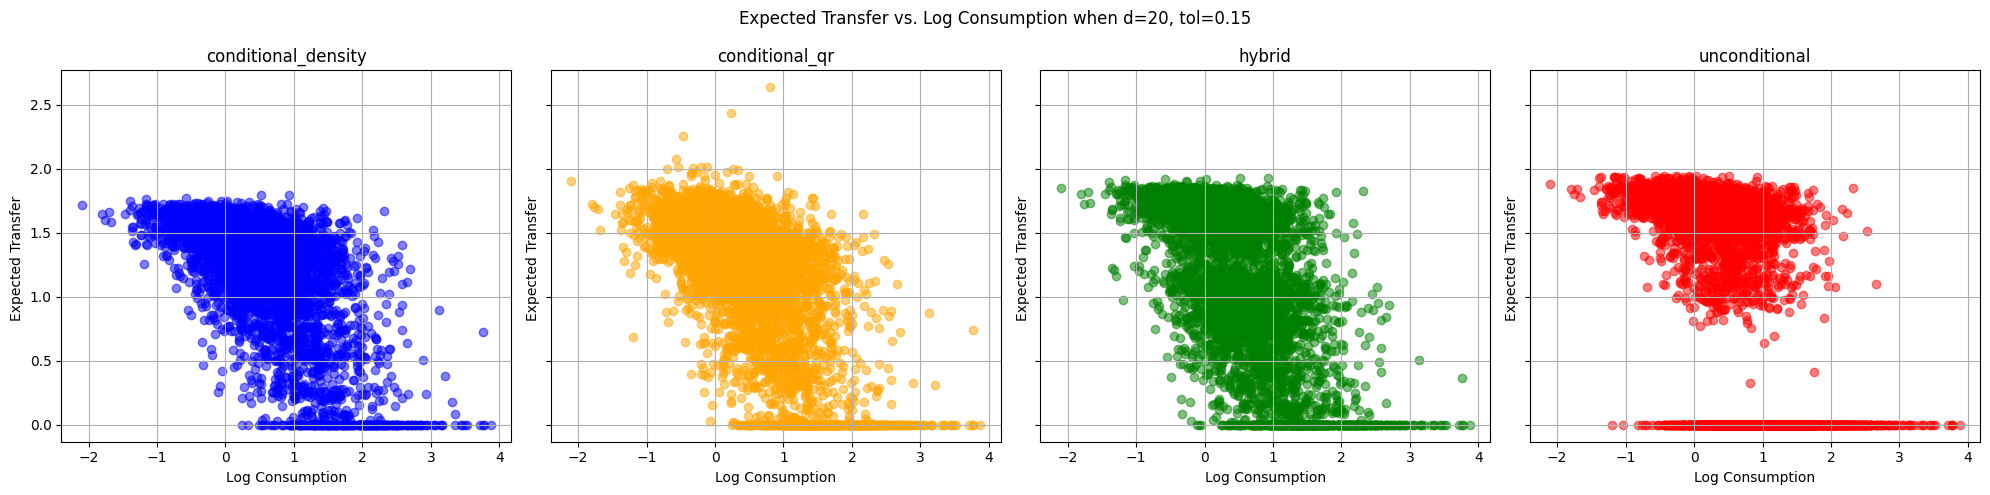

In [11]:
# Example usage
d = 20
tol = 0.15
plot_expected_transfer(d, tol)

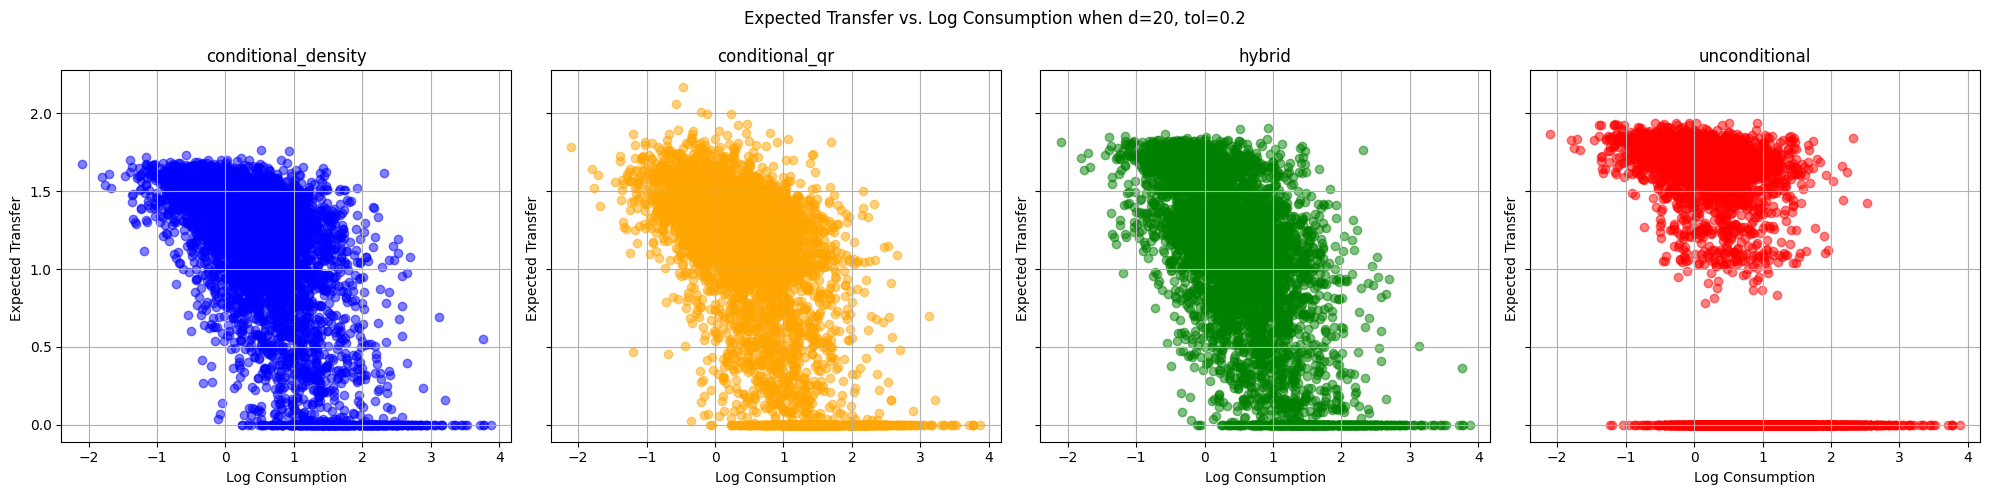

In [12]:
plot_expected_transfer(d, 0.2)